<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/ny_smells_multimodal_olfaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# [CELL 1 - Setup Environment and Install Dependencies]
import os
import sys
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List, Dict, Optional, Set

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Set random seeds for reproducible contrastive benchmark runs
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Compute Device: {device}")
if device.type == "cuda":
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
print("Environment successfully initialized.")

Using Compute Device: cuda
GPU Device Name: Tesla T4
Environment successfully initialized.


In [2]:
# [CELL 2 - Synthetic Multimodal Olfactory (E-Nose Signals) + Visual Image Generator]

class SyntheticOlfactoryVisualDataset:
    """
    Simulates in-the-wild paired visual images (64x64 RGB) and olfactory sensor signals
    (8-channel photoionization / E-nose time-series vectors) across 10 distinct object/material categories
    (e.g., coffee, asphalt, pine wood, floral, damp soil, metal, citrus, smoke, bakery, leather).
    """
    def __init__(self, num_samples: int = 500, num_categories: int = 10, sensor_channels: int = 8, seq_len: int = 32):
        self.num_samples = num_samples
        self.num_categories = num_categories
        self.sensor_channels = sensor_channels
        self.seq_len = seq_len

        # Category names simulating NY Smells dataset objects
        self.categories = [
            "Coffee Bean", "Pine Wood", "Fresh Asphalt", "Floral Garden", "Damp Soil",
            "Citrus Peel", "Bakery Bread", "Urban Smoke", "Leather Fabric", "Rusty Metal"
        ]

    def generate_dataset(s):
        images = []
        olfactory_signals = []
        labels = []

        # Ground-truth signature patterns per category
        np.random.seed(101)
        category_signatures = np.random.randn(s.num_categories, s.sensor_channels, s.seq_len).astype(np.float32)

        for i in range(s.num_samples):
            cat_idx = i % s.num_categories
            labels.append(cat_idx)

            # 1. Synthesize Olfactory Sensor Reading (Category signature + random sensor noise)
            noise = np.random.normal(0, 0.2, (s.sensor_channels, s.seq_len)).astype(np.float32)
            olf_signal = category_signatures[cat_idx] + noise
            olfactory_signals.append(olf_signal)

            # 2. Synthesize Paired Visual Image (Distinct color profile per category + spatial noise)
            img = np.random.uniform(0.1, 0.3, (3, 64, 64)).astype(np.float32)
            # Add category-specific color channel bias
            color_channel = cat_idx % 3
            img[color_channel] += 0.4

            # Spatial shape artifact
            r, c = (cat_idx * 5) % 30 + 10, (cat_idx * 7) % 30 + 10
            img[:, r:r+20, c:c+20] += 0.3
            images.append(img)

        images_tensor = torch.tensor(np.stack(images), dtype=torch.float32)
        olfactory_tensor = torch.tensor(np.stack(olfactory_signals), dtype=torch.float32)
        labels_tensor = torch.tensor(labels, dtype=torch.long)

        return images_tensor, olfactory_tensor, labels_tensor

dataset_gen = SyntheticOlfactoryVisualDataset(num_samples=600, num_categories=10)
imgs, olf_signals, cat_labels = dataset_gen.generate_dataset()

print(f"Dataset Generated: {imgs.shape[0]} Visual-Olfactory Pairs.")
print(f"Visual Image Dimensions: {imgs.shape[1:]} (RGB)")
print(f"Olfactory Sensor Dimensions: {olf_signals.shape[1:]} (Channels x Sequence Steps)")
print(f"Total Olfactory Categories: {len(dataset_gen.categories)}")

Dataset Generated: 600 Visual-Olfactory Pairs.
Visual Image Dimensions: torch.Size([3, 64, 64]) (RGB)
Olfactory Sensor Dimensions: torch.Size([8, 32]) (Channels x Sequence Steps)
Total Olfactory Categories: 10


In [3]:
# [CELL 3 - Vision Encoder, 1D-CNN Olfactory Encoder & Projection Heads]

class VisionEncoder(nn.Module):
    """Convolutional Backbone processing visual object images into feature representations."""
    def __init__(self, embed_dim: int = 128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),  # 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),# 8x8
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, embed_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class OlfactoryEncoder(nn.Module):
    """1D-CNN / Temporal Encoder processing multi-channel chemical sensor time-series."""
    def __init__(self, in_channels: int = 8, embed_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64, embed_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class VisionOlfactoryCLIPModel(nn.Module):
    """
    Multimodal Vision-Olfactory Contrastive Architecture:
    Projects visual and olfactory signals into a shared normalized embedding space.
    """
    def __init__(self, embed_dim: int = 128, proj_dim: int = 64, init_tau: float = 0.07):
        super().__init__()
        self.vision_encoder = VisionEncoder(embed_dim=embed_dim)
        self.olfactory_encoder = OlfactoryEncoder(in_channels=8, embed_dim=embed_dim)

        self.vision_proj = nn.Linear(embed_dim, proj_dim)
        self.olfactory_proj = nn.Linear(embed_dim, proj_dim)

        # Temperature parameter scaling
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1.0 / init_tau))

    def forward(self, imgs: torch.Tensor, olf_signals: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        # Extract features
        v_feat = self.vision_encoder(imgs)
        o_feat = self.olfactory_encoder(olf_signals)

        # Project to shared space
        v_emb = F.normalize(self.vision_proj(v_feat), p=2, dim=-1)
        o_emb = F.normalize(self.olfactory_proj(o_feat), p=2, dim=-1)

        tau = torch.exp(self.logit_scale)
        return v_emb, o_emb, tau

print("Vision-Olfactory CLIP Dual-Encoder Architecture initialized.")

Vision-Olfactory CLIP Dual-Encoder Architecture initialized.


In [4]:
# [CELL 4 - Symmetric InfoNCE Loss & Cross-Modal Retrieval (R@1, R@5, MRR)]

class VisionOlfactoryInfoNCELoss(nn.Module):
    """Symmetric Vision-to-Smell and Smell-to-Vision Contrastive Loss."""
    def __init__(self):
        super().__init__()

    def forward(self, v_emb: torch.Tensor, o_emb: torch.Tensor, tau: torch.Tensor) -> torch.Tensor:
        # Cosine similarity matrix: (B, B)
        logits = torch.matmul(v_emb, o_emb.T) * tau
        labels = torch.arange(v_emb.size(0), device=v_emb.device)

        loss_v2o = F.cross_entropy(logits, labels)
        loss_o2v = F.cross_entropy(logits.T, labels)
        return (loss_v2o + loss_o2v) / 2.0


def evaluate_cross_modal_retrieval(v_emb: torch.Tensor, o_emb: torch.Tensor) -> Dict[str, float]:
    """
    Evaluates Smell-to-Image and Image-to-Smell Retrieval metrics:
    Recall@1 (R@1), Recall@5 (R@5), and Mean Reciprocal Rank (MRR).
    """
    sim_matrix = torch.matmul(o_emb, v_emb.T).cpu().numpy()  # Query: Smell (O), Target: Vision (V)
    N = sim_matrix.shape[0]

    r1, r5, mrr = 0.0, 0.0, 0.0

    for i in range(N):
        scores = sim_matrix[i]
        ranked_indices = np.argsort(-scores)  # Descending order

        rank = np.where(ranked_indices == i)[0][0] + 1  # True match index (1-based)

        if rank == 1:
            r1 += 1.0
        if rank <= 5:
            r5 += 1.0
        mrr += 1.0 / rank

    return {
        "R@1": (r1 / N) * 100.0,
        "R@5": (r5 / N) * 100.0,
        "MRR": (mrr / N)
    }

print("InfoNCE Loss and Cross-Modal Retrieval Evaluator configured.")

InfoNCE Loss and Cross-Modal Retrieval Evaluator configured.


In [5]:
# [CELL 5 - Multimodal Contrastive Optimization Loop]

# Dataset Split (80% Train / 20% Test)
split = int(0.8 * len(imgs))
train_imgs, test_imgs = imgs[:split].to(device), imgs[split:].to(device)
train_olf, test_olf = olf_signals[:split].to(device), olf_signals[split:].to(device)
train_lbls, test_lbls = cat_labels[:split].to(device), cat_labels[split:].to(device)

model = VisionOlfactoryCLIPModel(embed_dim=128, proj_dim=64).to(device)
criterion = VisionOlfactoryInfoNCELoss().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 50
batch_size = 32

train_loss_hist = []
r1_hist = []

print("\n--- Starting Vision-Olfactory Multimodal Contrastive Training ---")
start_time = time.time()

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0

    permutation = torch.randperm(train_imgs.size(0))
    for i in range(0, train_imgs.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        b_imgs, b_olf = train_imgs[indices], train_olf[indices]

        if b_imgs.size(0) < 2:  # Skip single-item batch for contrastive loss
            continue

        optimizer.zero_grad()
        v_emb, o_emb, tau = model(b_imgs, b_olf)
        loss = criterion(v_emb, o_emb, tau)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * b_imgs.size(0)

    epoch_loss = running_loss / train_imgs.size(0)
    train_loss_hist.append(epoch_loss)

    # Validation Evaluation
    model.eval()
    with torch.no_grad():
        v_test, o_test, _ = model(test_imgs, test_olf)
        metrics = evaluate_cross_modal_retrieval(v_test, o_test)
        r1_hist.append(metrics["R@1"])

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{num_epochs} | InfoNCE Loss: {epoch_loss:.4f} | Smell-to-Image R@1: {metrics['R@1']:.2f}% | R@5: {metrics['R@5']:.2f}% | MRR: {metrics['MRR']:.3f}")

print(f"\nTraining completed in {time.time() - start_time:.2f} seconds.")


--- Starting Vision-Olfactory Multimodal Contrastive Training ---
Epoch 01/50 | InfoNCE Loss: 3.3477 | Smell-to-Image R@1: 2.50% | R@5: 13.33% | MRR: 0.114
Epoch 10/50 | InfoNCE Loss: 1.7067 | Smell-to-Image R@1: 9.17% | R@5: 40.83% | MRR: 0.258
Epoch 20/50 | InfoNCE Loss: 1.3228 | Smell-to-Image R@1: 9.17% | R@5: 38.33% | MRR: 0.258
Epoch 30/50 | InfoNCE Loss: 1.2593 | Smell-to-Image R@1: 7.50% | R@5: 35.00% | MRR: 0.246
Epoch 40/50 | InfoNCE Loss: 1.2844 | Smell-to-Image R@1: 4.17% | R@5: 44.17% | MRR: 0.229
Epoch 50/50 | InfoNCE Loss: 1.1770 | Smell-to-Image R@1: 6.67% | R@5: 41.67% | MRR: 0.250

Training completed in 6.94 seconds.


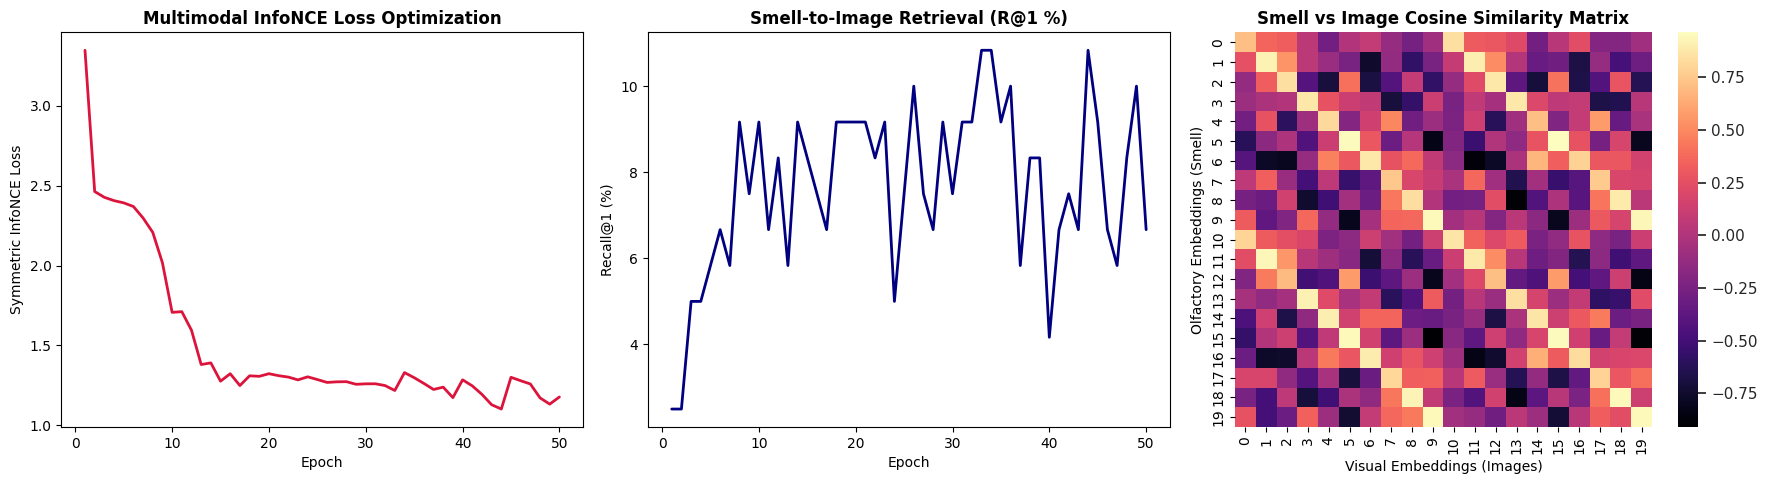


Benchmark visualization saved as ny_smells_multimodal_benchmark.png.


In [6]:
# [CELL 6 - Visualization Suite: Cross-Modal Similarity Matrix & Loss Curves]

model.eval()
with torch.no_grad():
    v_test, o_test, _ = model(test_imgs[:20], test_olf[:20])
    sim_matrix = torch.matmul(o_test, v_test.T).cpu().numpy()

# Plotting Results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# Plot 1: Contrastive Loss Convergence
axes[0].plot(range(1, num_epochs + 1), train_loss_hist, color='crimson', linewidth=2)
axes[0].set_title("Multimodal InfoNCE Loss Optimization", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Symmetric InfoNCE Loss")

# Plot 2: Cross-Modal Smell-to-Image Retrieval R@1 Curve
axes[1].plot(range(1, num_epochs + 1), r1_hist, color='navy', linewidth=2)
axes[1].set_title("Smell-to-Image Retrieval (R@1 %)", fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Recall@1 (%)")

# Plot 3: Cross-Modal Similarity Matrix Heatmap (20 Test Pairs)
sns.heatmap(sim_matrix, ax=axes[2], cmap="magma", cbar=True)
axes[2].set_title("Smell vs Image Cosine Similarity Matrix", fontweight='bold')
axes[2].set_xlabel("Visual Embeddings (Images)")
axes[2].set_ylabel("Olfactory Embeddings (Smell)")

plt.tight_layout()
plt.savefig("ny_smells_multimodal_benchmark.png", dpi=300)
plt.show()

print("\nBenchmark visualization saved as ny_smells_multimodal_benchmark.png.")